# Can LLMs Explain AI?
## Explainable AI for Cybersecurity Intrusion Detection

In [23]:
# ============================================================
# Install Dependencies
# ============================================================

!pip install shap lime -q



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [24]:
# ============================================================
# Imports
# ============================================================

# Standard library
import json
import os

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Explainability
import shap
from lime import lime_tabular

# OpenAI API
from openai import OpenAI

# Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# Model selection
from sklearn.model_selection import train_test_split

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


## Configuration

In [25]:
# ============================================================
# Configuration
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.30
SHAP_SAMPLE_SIZE = 200

DATASET_PATH = "../datasets/dataset1/Network_logs.csv"


## Dataset Loading

In [26]:
# ============================================================
# Dataset Loading
# ============================================================

df = pd.read_csv(DATASET_PATH)

# Create a safe copy
network_data = df.copy()

print(f"Dataset shape: {network_data.shape}")

network_data.head()


Dataset shape: (8846, 10)


,Source_IP,Destination_IP,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Intrusion,Scan_Type
0,192.168.142.55,42.156.67.167,80,FTP,UDP,2369,curl/7.68.0,Success,0,Normal
1,53.39.165.18,94.60.242.119,135,SMTP,UDP,1536,Wget/1.20.3,Failure,1,BotAttack
2,192.168.127.91,7.10.192.3,21,SMTP,TCP,1183,Wget/1.20.3,Success,0,Normal
3,192.168.30.40,130.169.82.211,25,HTTPS,TCP,666,Mozilla/5.0,Success,0,Normal
4,192.168.43.179,35.140.102.220,22,FTP,TCP,2821,Mozilla/5.0,Success,0,Normal


## Data Preprocessing

In [27]:
# ============================================================
# Data Preprocessing
# ============================================================

# Remove irrelevant/high-cardinality columns
columns_to_drop = [
    "Source_IP",
    "Destination_IP",
    "Intrusion"
]

network_data.drop(columns=columns_to_drop, inplace=True)

network_data.head()


,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type
0,80,FTP,UDP,2369,curl/7.68.0,Success,Normal
1,135,SMTP,UDP,1536,Wget/1.20.3,Failure,BotAttack
2,21,SMTP,TCP,1183,Wget/1.20.3,Success,Normal
3,25,HTTPS,TCP,666,Mozilla/5.0,Success,Normal
4,22,FTP,TCP,2821,Mozilla/5.0,Success,Normal


## Categorical Encoding

In [28]:
# ============================================================
# Categorical Feature Encoding
# ============================================================

categorical_columns = [
    "Request_Type",
    "Protocol",
    "User_Agent",
    "Status",
    "Port"
]

for column in categorical_columns:
    network_data[column] = (
        network_data[column]
        .astype("category")
        .cat.codes
    )


## Target Encoding

In [29]:
# ============================================================
# Target Encoding
# ============================================================

target_encoder = LabelEncoder()

network_data["Scan_Type_Label"] = target_encoder.fit_transform(
    network_data["Scan_Type"]
)

label_mapping = dict(
    zip(
        target_encoder.classes_,
        target_encoder.transform(target_encoder.classes_)
    )
)

print("Label Mapping:")
print(label_mapping)

network_data.drop(columns=["Scan_Type"], inplace=True)


Label Mapping:
{'BotAttack': np.int64(0), 'Normal': np.int64(1), 'PortScan': np.int64(2)}


## Feature Scaling

In [30]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

network_data["Payload_Size"] = scaler.fit_transform(
    network_data[["Payload_Size"]]
)


## Train/Test Split

In [31]:
# ============================================================
# Train/Test Split
# ============================================================

X = network_data.drop(columns=["Scan_Type_Label"])
y = network_data["Scan_Type_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (6192, 6)
Test set: (2654, 6)


## SMOTE Oversampling

In [32]:
# ============================================================
# SMOTE Oversampling
# ============================================================

smote = SMOTE(random_state=RANDOM_STATE)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

y_train = pd.Series(
    y_train,
    name="Scan_Type_Label"
)

print("SMOTE successfully applied.")
print(y_train.value_counts())


SMOTE successfully applied.
Scan_Type_Label
1    5600
0    5600
2    5600
Name: count, dtype: int64


## Balanced Target Distribution

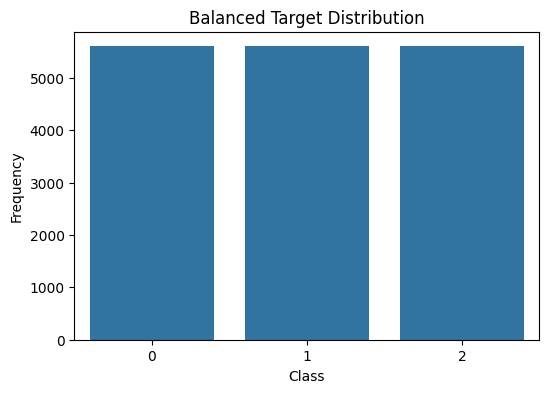

In [33]:
# ============================================================
# Target Distribution Visualization
# ============================================================

scan_type_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))

sns.barplot(
    x=scan_type_counts.index.astype(str),
    y=scan_type_counts.values
)

plt.title("Balanced Target Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")

plt.show()


## Random Forest Training

In [34]:
# ============================================================
# Random Forest Training
# ============================================================

rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9966

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       144
           1       1.00      1.00      1.00      2400
           2       0.99      1.00      1.00       110

    accuracy                           1.00      2654
   macro avg       0.98      0.99      0.99      2654
weighted avg       1.00      1.00      1.00      2654



## SHAP Explainability

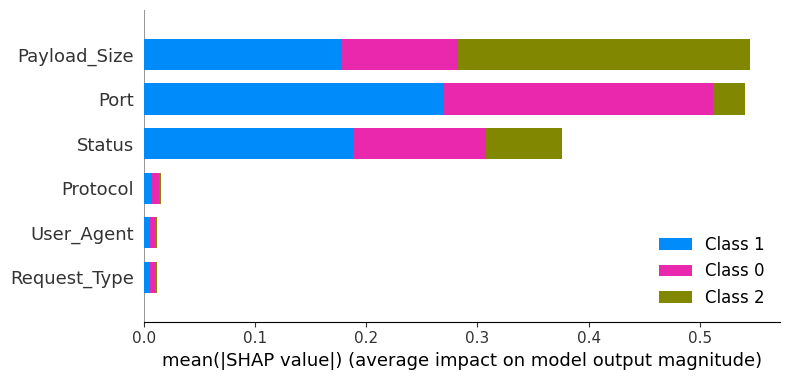

In [35]:
# ============================================================
# SHAP Explainability
# ============================================================

sample_idx = np.random.choice(
    X_test.index,
    size=min(SHAP_SAMPLE_SIZE, len(X_test)),
    replace=False
)

X_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)


## Confusion Matrix

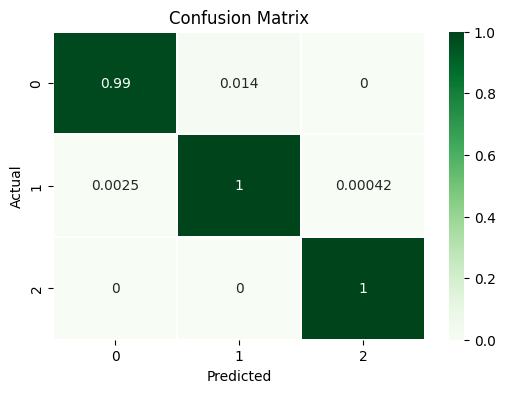

In [36]:
# ============================================================
# Confusion Matrix
# ============================================================

matrix = confusion_matrix(y_test, y_pred)

matrix = (
    matrix.astype("float")
    / matrix.sum(axis=1)[:, np.newaxis]
)

class_names = [
    "BotAttack",
    "Normal",
    "PortScan"
]

plt.figure(figsize=(6, 4))

sns.heatmap(
    matrix,
    annot=True,
    cmap="Greens",
    linewidths=0.2
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


## SHAP Global Feature Importance

In [37]:
# ============================================================
# SHAP Global Feature Importance
# ============================================================

feature_names = list(X.columns)

shap_global = {}

for class_idx, class_name in enumerate(class_names):

    mean_abs = np.abs(
        shap_values[:, :, class_idx]
    ).mean(axis=0)

    shap_global[class_name] = {
        feature: round(float(value), 6)
        for feature, value in zip(feature_names, mean_abs)
    }

print(json.dumps(
    shap_global,
    indent=2,
    ensure_ascii=False
))

################################################# ATTENTION ################################################
################### Do not send via prompt when you want to test without the SHAP values ###################
############################################################################################################

{
  "BotAttack": {
    "Port": 0.2422,
    "Request_Type": 0.005161,
    "Protocol": 0.006504,
    "Payload_Size": 0.104428,
    "User_Agent": 0.004786,
    "Status": 0.119533
  },
  "Normal": {
    "Port": 0.269959,
    "Request_Type": 0.00471,
    "Protocol": 0.007478,
    "Payload_Size": 0.177983,
    "User_Agent": 0.005461,
    "Status": 0.18809
  },
  "PortScan": {
    "Port": 0.028506,
    "Request_Type": 0.001827,
    "Protocol": 0.001388,
    "Payload_Size": 0.262323,
    "User_Agent": 0.001696,
    "Status": 0.068557
  }
}


## Prompt Construction

## LLM Context Information

In [38]:

# ============================================================
# LLM CONTEXT INFORMATION
# ============================================================

model_info = {
    "model_type": "Random Forest",
    "task": (
        "Intrusion detection using network logs. "
        "Each log is classified as BotAttack (0), "
        "Normal (1), or PortScan (2)."
    ),
    "target_variable": "Scan_Type_Label",
    "features": list(X.columns)
}

# ==========================
# COLUMN DESCRIPTION
# ==========================

column_description = {
    "Port": "Port used in the communication",
    "Request_Type": "Type of request",
    "Protocol": "Transport Layer protocol according to the OSI model",
    "Payload_Size": "Packet payload size",
    "User_Agent": "User agent used in the communication",
    "Status": "Request status",
    "Scan_Type_Label": "Communication classification: BotAttack, Normal, or PortScan"
}

# ==========================
# CATEGORY ENCODING
# ==========================

category_encoding = {

    "Request_Type": {
        "DNS": 0,
        "FTP": 1,
        "HTTP": 2,
        "HTTPS": 3,
        "SMTP": 4,
        "SSH": 5,
        "Telnet": 6
    },

    "Protocol": {
        "ICMP": 0,
        "TCP": 1,
        "UDP": 2
    },

    "User_Agent": {
        "Mozilla/5.0": 0,
        "Nikto/2.1.6": 1,
        "Wget/1.20.3": 2,
        "curl/7.68.0": 3,
        "nmap/7.80": 4,
        "python-requests/2.25.1": 5
    },

    "Status": {
        "Failure": 0,
        "Success": 1
    },

    "Port": {
        21: 0,
        22: 1,
        23: 2,
        25: 3,
        53: 4,
        80: 5,
        135: 6,
        443: 7,
        4444: 8,
        6667: 9,
        8080: 10,
        31337: 11
    },

    "Scan_Type_Label": {
        "BotAttack": 0,
        "Normal": 1,
        "PortScan": 2
    }
}

# ==========================
# TRAINING DATA SAMPLE
# ==========================

train_sample = X_train.sample(50)
train_sample["Scan_Type_Label"] = y_train.loc[train_sample.index]
train_sample_json = train_sample.to_json(orient="records")

# ==========================
# PREDICTION SAMPLE
# ==========================

pred_sample = pd.DataFrame({
    "real": y_test,
    "predicted": y_pred
})
pred_sample_json = pred_sample.sample(50).to_json(orient="records")


In [39]:
# ============================================================
# Prompt Construction
# ============================================================

prompt = f"""
You are an expert in Explainable Artificial Intelligence (XAI)
and Cybersecurity.

Analyze the machine learning model and provide a clear,
technical, and objective explanation of its behavior.

=========================
MODEL INFORMATION
=========================
{model_info}

=========================
COLUMN DESCRIPTION
=========================
{column_description}

=========================
CATEGORY ENCODING
=========================
{category_encoding}

=========================
TRAINING DATA SAMPLE
=========================
{train_sample_json}

=========================
PREDICTION SAMPLE
=========================
{pred_sample_json}

=========================
SHAP GLOBAL IMPORTANCE
=========================
{json.dumps(shap_global, indent=2, ensure_ascii=False)} # Do not send via prompt when you want to test without the SHAP values.

=========================
TASK
=========================

1. Identify the top-3 most relevant features for each class.
2. Compare differences between classes.
3. Interpret model behavior in the cybersecurity context.
4. Avoid causal claims — describe only associations.

The explanation should be understandable for both technical
and non-technical users.
"""


## GPT-5 Explainability

In [40]:
# ============================================================
# GPT-5 Explainability
# ============================================================

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    timeout=300,
)

response = client.responses.create(
    model="gpt-5",
    input=[
        {
            "role": "system",
            "content": (
                "You are an expert in Machine Learning "
                "and Explainable AI."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    max_output_tokens=12288
)


## Extract LLM Explanation

In [41]:
# ============================================================
# Extract LLM Explanation
# ============================================================

explanation = ""

for item in response.output:

    if item.type == "message":

        for content in item.content:

            if content.type == "output_text":
                explanation += content.text

print("\n===== MODEL EXPLANATION =====\n")
print(explanation)



===== MODEL EXPLANATION =====

Summary of how the model makes decisions
- The model is a Random Forest that classifies each network log as BotAttack, Normal, or PortScan using six inputs: Port, Request_Type, Protocol, Payload_Size, User_Agent, and Status.
- SHAP (SHapley) values quantify how much each feature contributes to each class decision on average (higher = more influential). These are associations within this dataset; they do not imply causation or direction (e.g., “higher” or “lower” increases risk can’t be concluded from global magnitudes alone).

1) Top-3 most relevant features per class (from SHAP global importance)
- BotAttack
  1. Port: 0.2422
  2. Status: 0.1195
  3. Payload_Size: 0.1044
- Normal
  1. Port: 0.2700
  2. Status: 0.1881
  3. Payload_Size: 0.1780
- PortScan
  1. Payload_Size: 0.2623
  2. Status: 0.0686
  3. Port: 0.0285

Lower-impact features for all classes: Protocol, Request_Type, and User_Agent (all near ~0.002–0.007).

Important note on encodings:
- Por

## Local LLM Support

In [42]:
# ============================================================
# Local LLM Integration
# ============================================================

# Adapt this section to test local/open-source LLMs
# such as:
#
# - GPT-OSS-20B
# - Llama 3
# - Mistral
# - DeepSeek
#
# Example frameworks:
# - Ollama
# - vLLM
# - LM Studio
# - Transformers


In [43]:
# ============================================================
# Local LLM via Ollama (OpenAI-compatible endpoint)
# ============================================================

local_client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
    timeout=300
)

local_response = local_client.responses.create(
    model="gpt-oss:20b-cloud",
    input=[
        {
            "role": "system",
            "content": (
                "You are an expert in Machine Learning "
                "and Explainable AI."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    max_output_tokens=12288
)

local_explanation = ""

for item in local_response.output:
    if item.type == "message":
        for content in item.content:
            if content.type == "output_text":
                local_explanation += content.text

print("\n===== LOCAL LLM EXPLANATION =====\n")
print(local_explanation)



===== LOCAL LLM EXPLANATION =====

**1.  Top‑3 influential features for each class (by SHAP importance)**  

| Class     | 1st          | 2nd          | 3rd          |
|-----------|--------------|--------------|--------------|
| **BotAttack** | **Port** (0.242) | **Status** (0.120) | **Payload_Size** (0.104) |
| **Normal** | **Port** (0.270) | **Status** (0.188) | **Payload_Size** (0.178) |
| **PortScan**| **Payload_Size** (0.262) | **Port** (0.029) | **Status** (0.069) |

(The numbers are the average absolute SHAP values for that feature when the model predicts the given class.)

**2.  How the feature importance differs between classes**

| Feature | BotAttack | Normal | PortScan |
|---------|-----------|--------|----------|
| **Port** | Very high (0.24) – the particular port used strongly pushes the model toward “BotAttack.” | Highest (0.27) – common ports used on normal traffic give the biggest positive contribution to “Normal.” | Small (0.03) – port choice is weakly associated wit